In [1]:
import sys
import numpy as np
import os
import json

# Add the directory containing instruments.py to the Python path
custom_module_path = "/home/rebeccaz/Github/vampires_calibration"
sys.path.append(custom_module_path)

import plotting_rewrite as plotting
import instruments_jax as inst

h5_file_path = "/home/rebeccaz/Github/vampires_calibration/mcmc/results/610nm_Adjusted_EM_Gain_Shared_Priors_20000000_steps.h5"
txt_file_path = "/home/rebeccaz/Github/vampires_calibration/scipy_minimize/data_files/produced/675-50nm_no_IMR_offset_or_IMR_and_HWP_constraints.txt"
txt_save_file_path = "/home/rebeccaz/Github/vampires_calibration/mcmc/results/610nm_Adjusted_EM_Gain_Shared_Priors_20000000_steps.txt"

# Step 1: Defining System Dictionary

In [2]:
filter_wavelength = 610
wavelength_string = filter_wavelength
wavelength_index = 0
nsteps = 20000000
obs_mode = "MBI"

IPOL_em_gains = [1.14, 1.18, 1.18, 1.18]
MBI_em_gains = [1.23, 1.19, 1.2, 1.08]
if obs_mode == "IPOL":
    em_gain = IPOL_em_gains[wavelength_index]
elif obs_mode == "MBI":
    em_gain = MBI_em_gains[wavelength_index]

system_dict = {
    "components": {
        "wollaston": {
            "type": "wollaston_prism_function",
            "properties": {"beam": "o", "transmission_ratio": em_gain},
        },
        "dichroic": {
            "type": "diattenuator_retarder_function",
            "properties": {"phi": 0, "epsilon": 0, "theta" : 0},
        },
        "flc": {
            "type": "general_retarder_function",
            "properties": {"phi": 0.5 * 2 * np.pi, "theta": 0, "delta_theta": 0},
        },
        "optics": {
            "type": "diattenuator_retarder_function",
            "properties": {"phi": 0, "epsilon": 0, "theta": 0},
        },
        "image_rotator": {
            "type": "general_retarder_function",
            "properties": {"phi": 0.5 * 2 * np.pi, "theta": 0, "delta_theta": 0},
        },
        "hwp": {
            "type": "general_retarder_function",
            "properties": {"phi": 0.5 * 2 * np.pi, "theta": 0, "delta_theta": 0},
        },
        "lp": {
            "type": "general_linear_polarizer_function_with_theta",
            "properties": {"theta": 0},
        },
    }
}

# Step 2: Loading Chains

dichroic.phi (waves): 0.02587 ± 0.00436
dichroic.epsilon (): 0.53477 ± 0.13334
dichroic.theta (): 45.49710 ± 4.95795
flc.phi (waves): 0.48576 ± 0.00557
flc.delta_theta (): -4.86705 ± 0.17537
optics.phi (waves): 0.18111 ± 0.00571
optics.epsilon (): 0.01645 ± 0.00290
optics.theta (): 6.29196 ± 0.65087
image_rotator.phi (waves): 0.21845 ± 0.00159
hwp.phi (waves): 0.44027 ± 0.00212
hwp.delta_theta (): -0.28575 ± 0.67630
lp.theta (): 0.25198 ± 0.54420
log_f (): -4.44737 ± 0.36587
Chain shape (nsteps, nwalkers, ndim): (43910, 28, 13)


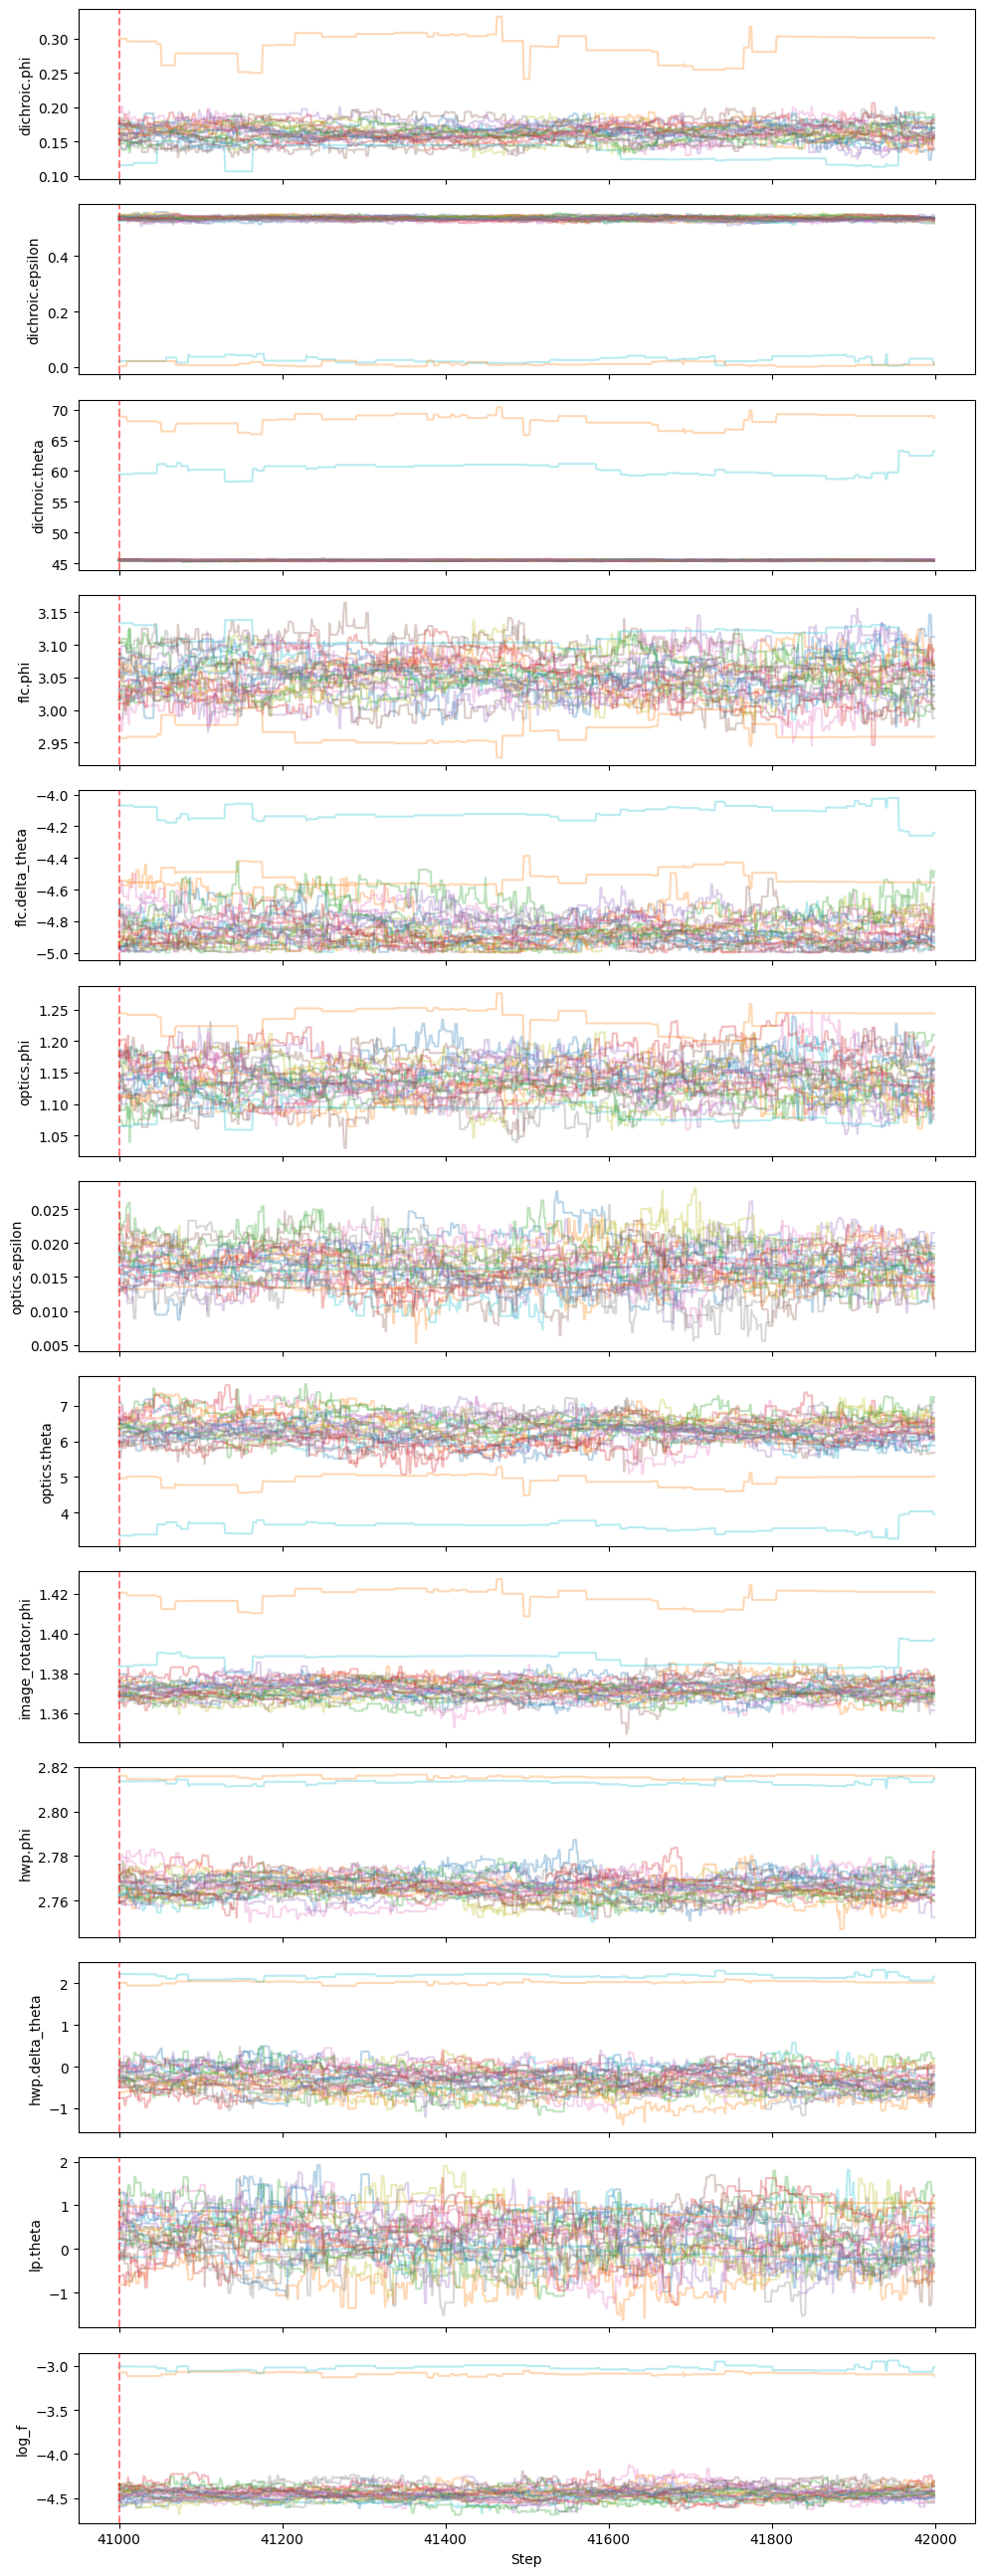

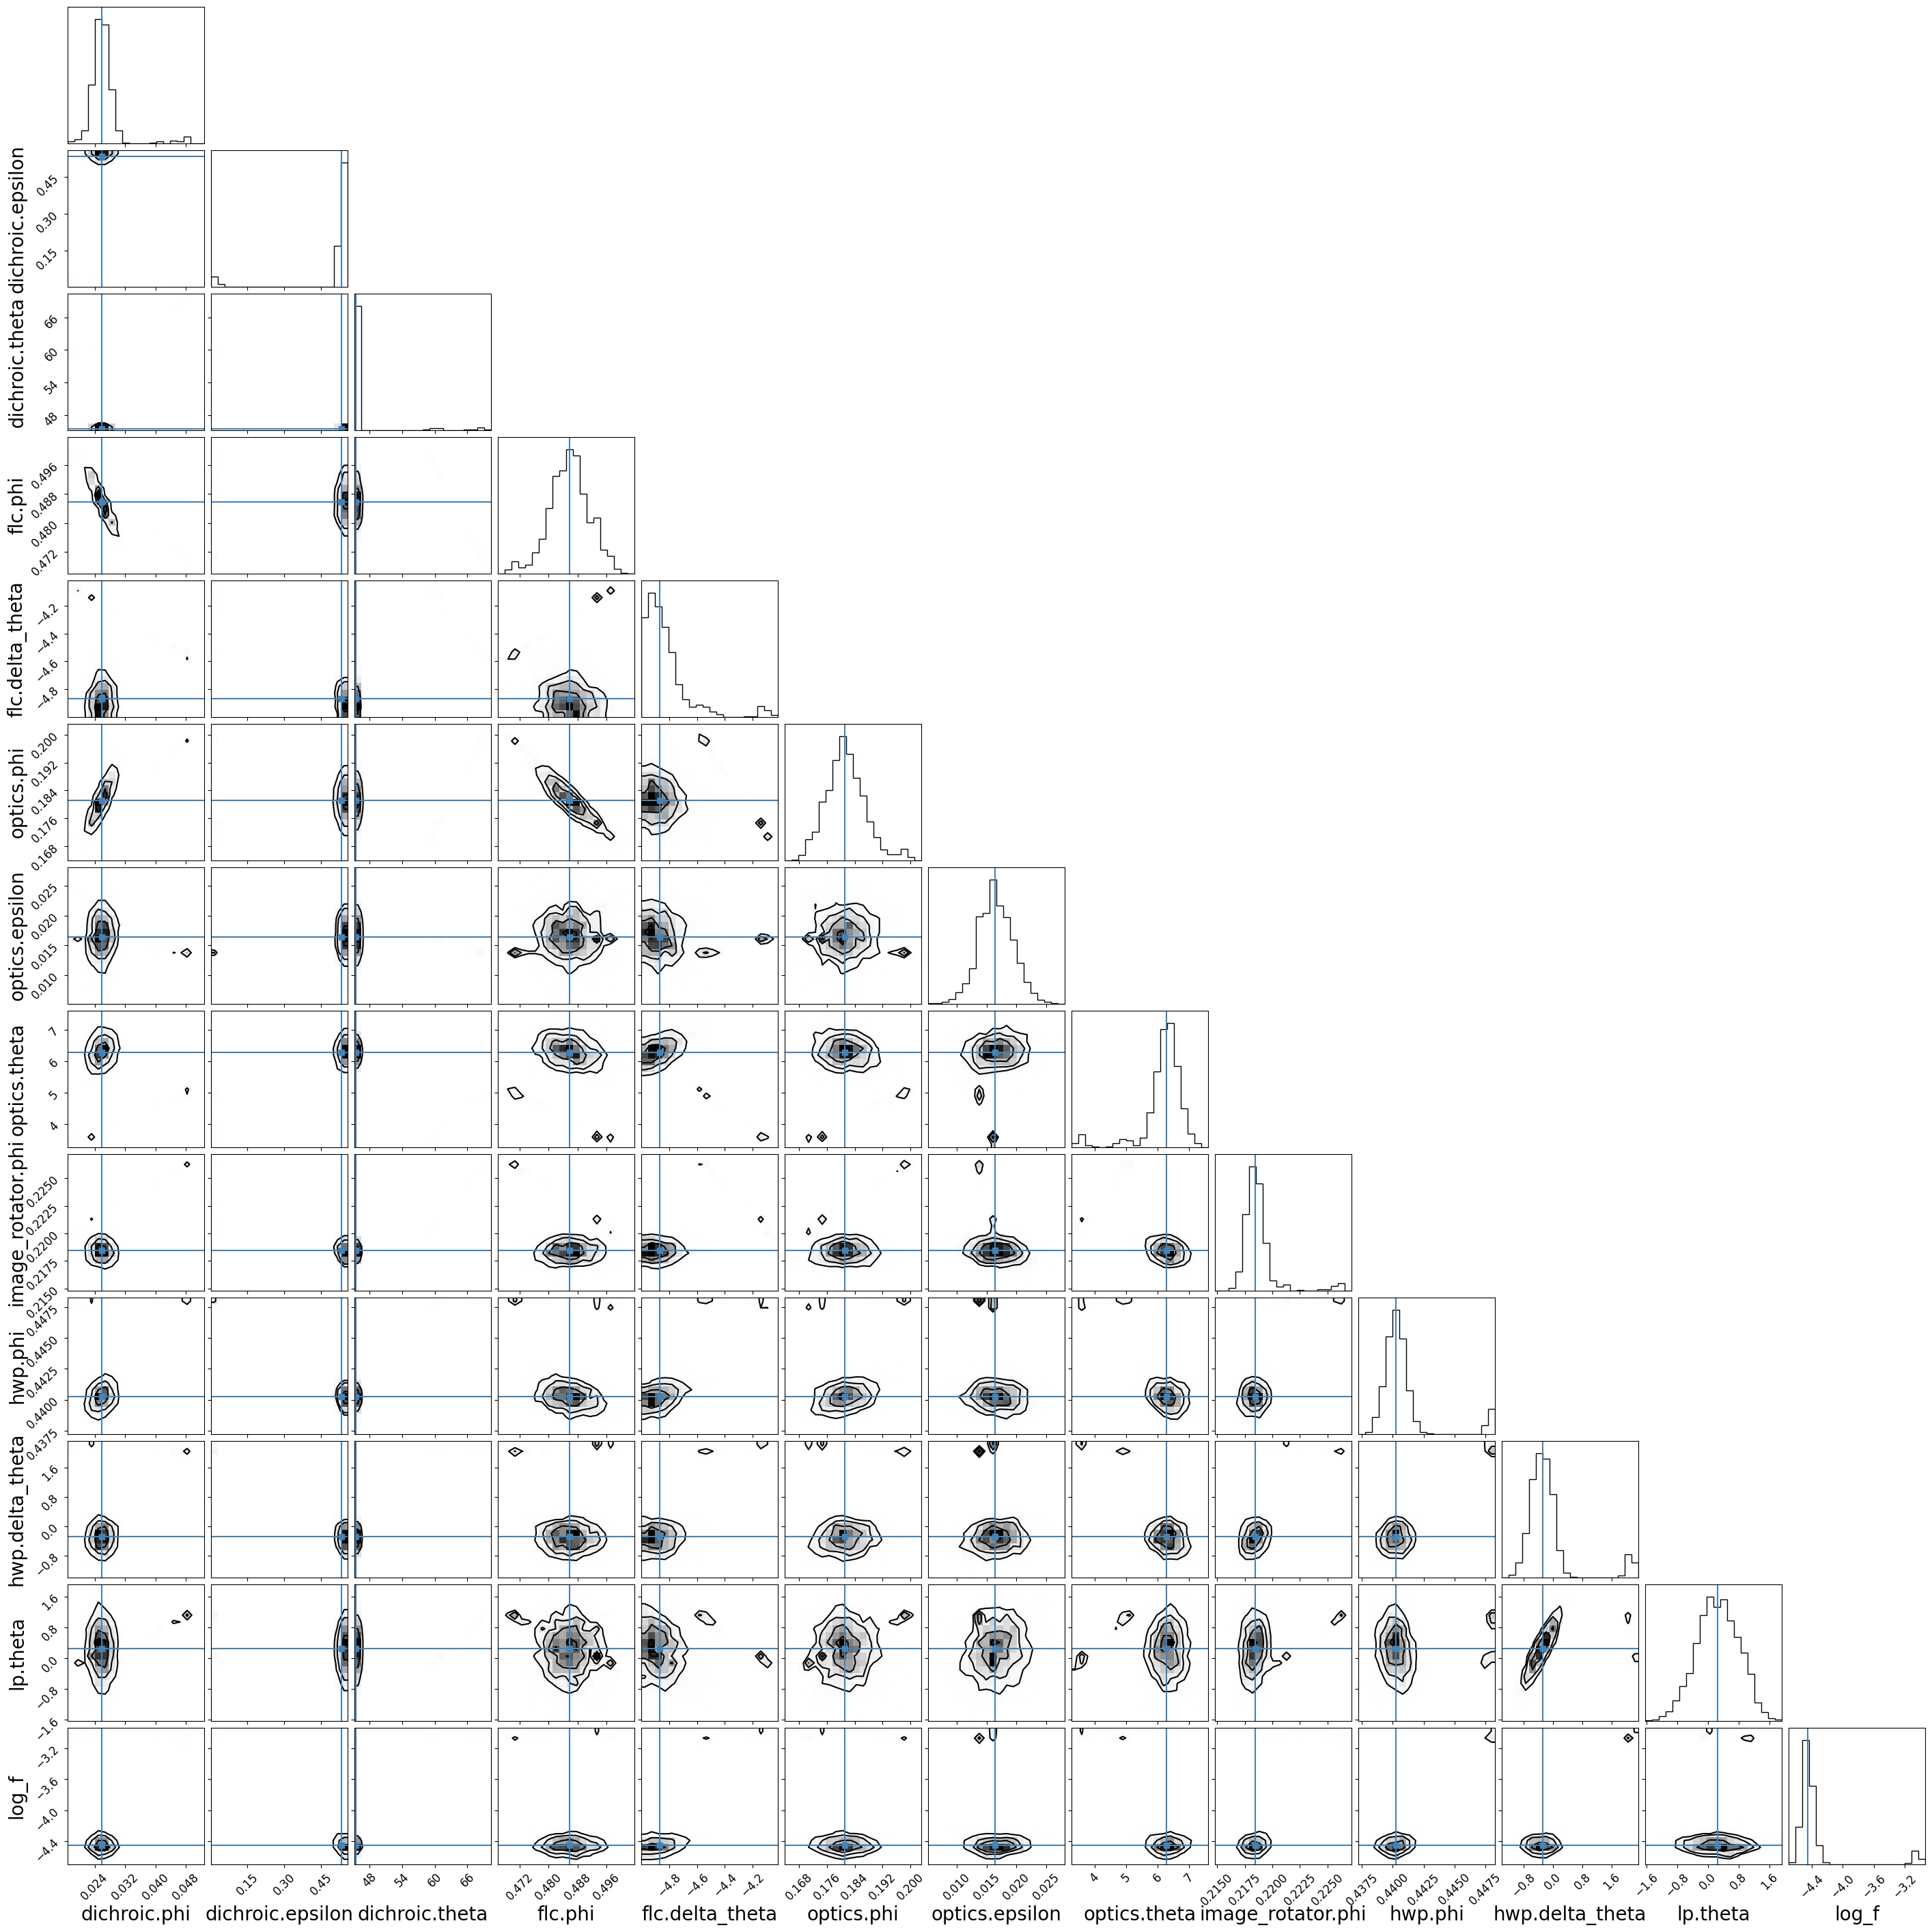

In [3]:
chain, names = plotting.load_chain_and_labels(h5_file_path, txt_file_path, include_logf = True)
chain_step_range = (41000, 42000)
corner_plot_step_range = (41000, 42000)

# Print median ± std for each parameter
plotting.summarize_posteriors(chain, names, system_dict, step_range=corner_plot_step_range, 
    txt_save_file_path = txt_save_file_path, txt_file_path = txt_file_path)

# Check chain shape after loading
print("Chain shape (nsteps, nwalkers, ndim):", chain.shape)

# Plot trace plots for MCMC chains
plotting.plot_trace(chain, names, step_range=chain_step_range, max_walkers=100)

# Plot corner plot from flattened chain
plotting.plot_corner_flat(chain, names, step_range=corner_plot_step_range)


## Step 2.5: Autocorrelation Time Diagnostics

In [4]:
import emcee

# Use the full loaded chain by default. Set a different range to estimate tau after burn-in.
autocorr_step_range = (0, None)
autocorr_thin = 1
autocorr_tol = 0  # Use 50 for emcee's usual convergence check; 0 always returns an estimate.

act_start, act_end = autocorr_step_range
if act_end is None:
    act_end = chain.shape[0]

if act_start < 0 or act_end > chain.shape[0] or act_start >= act_end:
    raise ValueError(f"Invalid autocorr_step_range {autocorr_step_range} for chain with {chain.shape[0]} steps.")

act_chain = chain[act_start:act_end:autocorr_thin, :, :]
if act_chain.shape[0] < 2:
    raise ValueError("Autocorrelation calculation needs at least two saved steps.")

autocorr_tau = emcee.autocorr.integrated_time(act_chain, tol=autocorr_tol, quiet=True)
autocorr_tau_steps = autocorr_tau * autocorr_thin
autocorr_nsteps = act_end - act_start
autocorr_neff = act_chain.shape[0] * act_chain.shape[1] / autocorr_tau

print(f"Autocorrelation step range: {act_start} to {act_end} (thin={autocorr_thin})")
print(f"{'parameter':<35} {'tau [steps]':>12} {'nsteps/tau':>12} {'N_eff':>12}")
for name, tau_steps, neff in zip(names, autocorr_tau_steps, autocorr_neff):
    print(f"{name:<35} {tau_steps:12.1f} {autocorr_nsteps / tau_steps:12.1f} {neff:12.0f}")

print(f"Mean tau: {np.mean(autocorr_tau_steps):.1f} steps")
print(f"Max tau: {np.max(autocorr_tau_steps):.1f} steps")
print(f"Recommended burn-in: {int(2 * np.max(autocorr_tau_steps))} steps")
print(f"Recommended thinning: {max(1, int(0.5 * np.min(autocorr_tau_steps)))} steps")


Autocorrelation step range: 0 to 43910 (thin=1)
parameter                            tau [steps]   nsteps/tau        N_eff
dichroic.phi                               209.9        209.2         5857
dichroic.epsilon                           818.9         53.6         1501
dichroic.theta                             735.4         59.7         1672
flc.phi                                    251.8        174.4         4883
flc.delta_theta                            770.1         57.0         1596
optics.phi                                 291.5        150.6         4218
optics.epsilon                             362.5        121.1         3392
optics.theta                               260.2        168.7         4724
image_rotator.phi                          526.5         83.4         2335
hwp.phi                                   1203.1         36.5         1022
hwp.delta_theta                            470.8         93.3         2611
lp.theta                                   317.2    

# Step 3: Plot median configuration of posteriors

In [5]:
file_path = "/home/rebeccaz/Github/vampires_calibration/data/20230914_processed_table.csv"

interleaved_values, interleaved_stds, configuration_list = inst.read_csv(file_path, 
    obs_mode = obs_mode, obs_filter = wavelength_string)

In [6]:
# Loading in median parameters
with open(txt_save_file_path, "r") as f:
    past_fit = json.load(f)

# print(past_fit)

theta_pol = past_fit["lp"]["theta"]
delta_HWP = past_fit["hwp"]["phi"] 
offset_HWP = past_fit["hwp"]["delta_theta"]
delta_derot = past_fit["image_rotator"]["phi"] 
delta_opts = past_fit["optics"]["phi"]
epsilon_opts = past_fit["optics"]["epsilon"]
rot_opts = past_fit["optics"]["theta"]
delta_FLC = past_fit["flc"]["phi"] 
rot_FLC = past_fit["flc"]["delta_theta"]
delta_dichroic = past_fit["dichroic"]["phi"]
epsilon_dichroic = past_fit["dichroic"]["epsilon"]
rot_dichroic = past_fit["dichroic"]["theta"]

print(delta_HWP)

# NOTE: Components must be listed downstream to upstream
# Define the instrument configuration as a system dictionary

system_dict = {
    "components": {
        "wollaston": {
            "type": "wollaston_prism_function",
            "properties": {"beam": "o", "transmission_ratio": em_gain},
        },
        "dichroic": {
            "type": "diattenuator_retarder_function",
            "properties": {
                "phi": delta_dichroic * 2 * np.pi,
                "epsilon": epsilon_dichroic,
                "theta": rot_dichroic,
            },
        },
        "flc": {
            "type": "general_retarder_function",
            "properties": {
                "phi": delta_FLC * 2 * np.pi,
                "theta": 0,  # not fitted
                "delta_theta": rot_FLC,
            },
        },
        "optics": {
            "type": "diattenuator_retarder_function",
            "properties": {
                "phi": delta_opts * 2 * np.pi,
                "epsilon": epsilon_opts,
                "theta": rot_opts,
            },
        },
        "image_rotator": {
            "type": "general_retarder_function",
            "properties": {
                "phi": delta_derot * 2 * np.pi,
                "theta": 0,  # not fitted
                "delta_theta": 0,  # not fitted
            },
        },
        "hwp": {
            "type": "general_retarder_function",
            "properties": {
                "phi": delta_HWP * 2 * np.pi,
                "theta": 0,  # not fitted
                "delta_theta": offset_HWP,
            },
        },
        "lp": {
            "type": "general_linear_polarizer_function_with_theta",
            "properties": {"theta": theta_pol},
        },
    }
}

system_mm = inst.generate_system_mueller_matrix(system_dict)
print(system_mm.evaluate())


0.4402707702166221
[[0.47085966 0.47084145 0.00414159 0.        ]
 [0.47085966 0.47084145 0.00414159 0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]]


logl value: 21335.933717436375


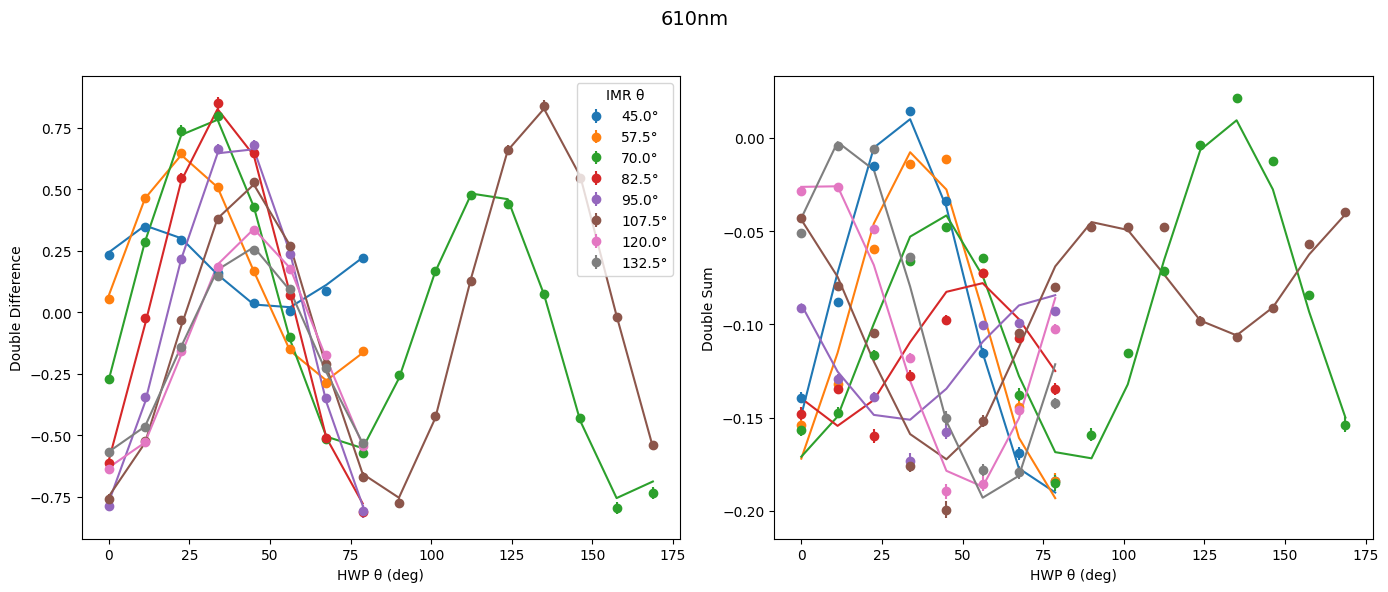

In [7]:
# Fittin for all parameters

p0 = {
    "wollaston": {"transmission_ratio": em_gain}, 
}

p0_values, p0_keywords = inst.parse_configuration(p0)
s_in = np.array([1, 0, 0, 0])
logl_value = inst.logl(p0_values, p0_keywords, system_mm, interleaved_values, interleaved_stds, configuration_list,
    s_in=s_in, logl_function=None, process_dataset=inst.process_dataset, process_errors=inst.process_errors, 
    process_model=inst.process_model)
print("logl value: " + str(logl_value))

# TODO: Add an initial plot block here
# Plotting intial plot
# updated_system_mm = inst.update_system_mm(p0_values, p0_keywords, system_mm)
model = inst.model(p0_values, p0_keywords, system_mm, configuration_list, 
    process_model = inst.process_model)

inst.plot_data_and_model(interleaved_values, interleaved_stds, model, 
    configuration_list, wavelength = wavelength_string)

# Step 4: Plotting Random Chains for Fitting (UNDER CONSTRUCTION)

Plotting 100 random chain samples from steps 41000 to 42000.
Selected (step, walker) pairs:
[(41436, 24), (41939, 18), (41669, 9), (41465, 26), (41449, 9), (41776, 27), (41154, 1), (41325, 12), (41164, 24), (41715, 8), (41182, 1), (41496, 27), (41431, 15), (41820, 18), (41370, 1), (41695, 2), (41831, 26), (41200, 22), (41885, 23), (41966, 7), (41226, 19), (41921, 6), (41891, 12), (41127, 20), (41160, 16), (41837, 8), (41794, 23), (41189, 7), (41758, 15), (41139, 21), (41239, 14), (41553, 7), (41699, 25), (41524, 22), (41544, 1), (41288, 8), (41904, 13), (41783, 19), (41642, 4), (41767, 15), (41091, 25), (41841, 13), (41545, 20), (41387, 11), (41442, 8), (41475, 8), (41629, 11), (41067, 22), (41758, 22), (41226, 20), (41652, 8), (41897, 25), (41682, 2), (41366, 4), (41444, 23), (41462, 13), (41924, 6), (41511, 19), (41733, 13), (41742, 8), (41401, 10), (41369, 21), (41771, 6), (41076, 7), (41636, 20), (41682, 12), (41825, 22), (41085, 18), (41276, 4), (41097, 5), (41968, 23), (41756, 14

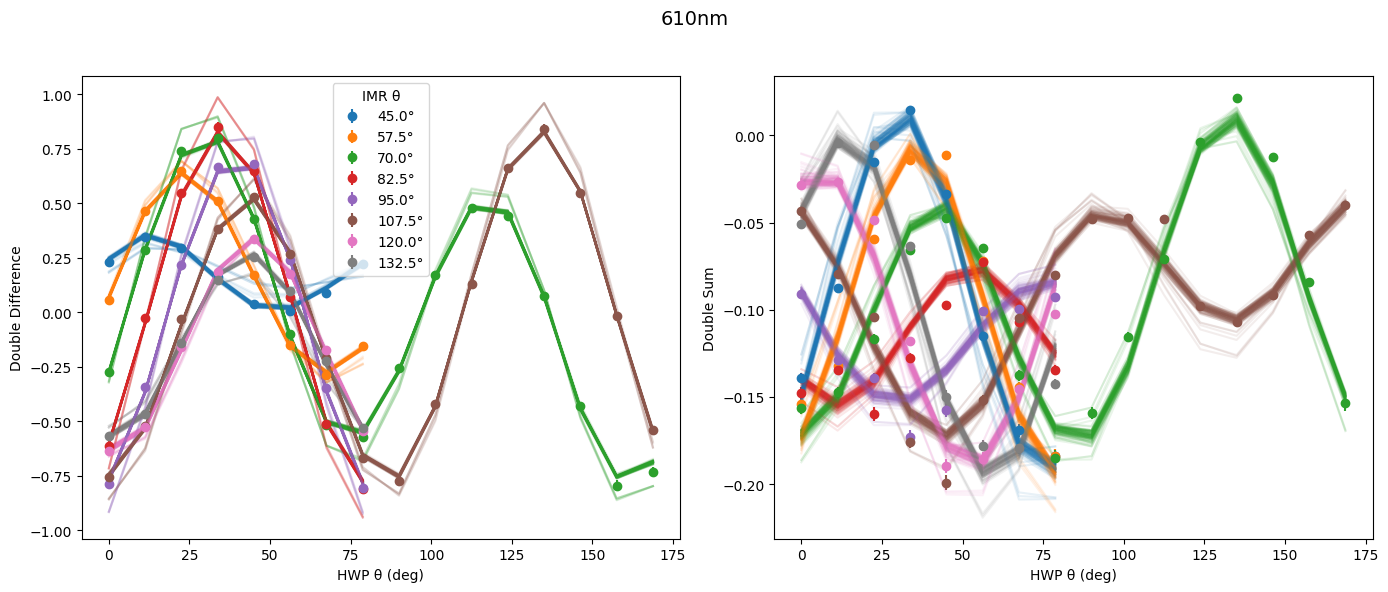

In [8]:
import importlib
inst = importlib.reload(inst)

# User settings
n_random_chains = 100
random_chain_step_range = corner_plot_step_range
random_chain_alpha = 0.1
random_seed = 42
imr_theta_filter = None

with open(txt_file_path, "r") as f:
    fit_param_dict = json.load(f)
_, fit_param_keys = inst.parse_configuration(fit_param_dict)

start, end = random_chain_step_range
if end is None:
    end = chain.shape[0]

if start < 0 or end > chain.shape[0] or start >= end:
    raise ValueError(f"Invalid random_chain_step_range {random_chain_step_range} for chain with {chain.shape[0]} steps.")

chain_window = chain[start:end, :, :]
flat_chain_window = chain_window.reshape(-1, chain.shape[-1])
n_available_samples = flat_chain_window.shape[0]

if chain.shape[-1] < len(fit_param_keys):
    raise ValueError(f"Chain has {chain.shape[-1]} parameters, but {len(fit_param_keys)} fitted parameters were found.")

if n_random_chains > n_available_samples:
    raise ValueError(f"Only {n_available_samples} samples available, but {n_random_chains} requested.")

rng = np.random.default_rng(random_seed)
selected_flat_indices = rng.choice(n_available_samples, size=n_random_chains, replace=False)
selected_steps = start + (selected_flat_indices // chain.shape[1])
selected_walkers = selected_flat_indices % chain.shape[1]
random_chain_samples = flat_chain_window[selected_flat_indices, :len(fit_param_keys)]
random_chain_system_mm = inst.generate_system_mueller_matrix(system_dict)
s_in_random = globals().get("s_in", np.array([1, 0, 0, 0]))

random_chain_models = [
    inst.model(
        sample,
        fit_param_keys,
        random_chain_system_mm,
        configuration_list,
        s_in=s_in_random,
        process_model=inst.process_model,
    )
    for sample in random_chain_samples
]

print(f"Plotting {n_random_chains} random chain samples from steps {start} to {end}.")
print("Selected (step, walker) pairs:")
print(list(zip(selected_steps.tolist(), selected_walkers.tolist())))

inst.plot_data_and_model(
    interleaved_values,
    interleaved_stds,
    random_chain_models,
    configuration_list,
    wavelength=wavelength_string,
    imr_theta_filter=imr_theta_filter,
    model_alpha=random_chain_alpha,
    first_model_alpha=random_chain_alpha,
)


In [9]:
# import sys
# import os

# # Add the directory containing instruments.py to the Python path
# custom_module_path = "/home/rebeccaz/Github/vampires_calibration"
# sys.path.append(custom_module_path)

# import plotting_rewrite as plotting
# import numpy as np

# all_step_range = (0, None)
# corner_plot_step_range = (24000, 25000)

# # Define the system configuration dictionary
# system_dict = {
#     "components": {
#         "wollaston": {
#             "type": "wollaston_prism_function",
#             "properties": {"beam": "o", "transmission_ratio": 1.18},
#         },
#         "dichroic": {
#             "type": "diattenuator_retarder_function",
#             "properties": {"phi": 0, "epsilon": 0, "theta": 0},
#         },
#         "flc": {
#             "type": "general_retarder_function",
#             "properties": {"phi": 0.5 * 2 * np.pi, "theta": 0, "delta_theta": 0},
#         },
#         "optics": {
#             "type": "diattenuator_retarder_function",
#             "properties": {"phi": 0, "epsilon": 0, "theta": 0},
#         },
#         "image_rotator": {
#             "type": "general_retarder_function",
#             "properties": {"phi": 0.5 * 2 * np.pi, "theta": 0, "delta_theta": 0},
#         },
#         "hwp": {
#             "type": "general_retarder_function",
#             "properties": {"phi": 0.5, "theta": 0, "delta_theta": 0},
#         },
#         "lp": {
#             "type": "general_linear_polarizer_function_with_theta",
#             "properties": {"theta": 0},
#         },
#     }
# }

# # Input paths and call plotting function
# h5_filename = "675nm_no_IMR_offset_with_dichroic.h5"
# txt_filename = "675-50nm.txt"
# csv_file_path = "/home/rebeccaz/Github/vampires_calibration/data/20230914_processed_table.csv"

# plotting.plot_mcmc_fits_double_diff_sum(
#     h5_filename=h5_filename,
#     txt_filename=txt_filename,
#     csv_path=csv_file_path,
#     filter_wavelength="675-50",
#     system_dict=system_dict,
#     wavelength_str="675nm",
#     n_samples=50,
#     step_range = all_step_range
# )
